<a href="https://colab.research.google.com/github/sushant758/Deep-Learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
!pip install -q kagglehub

In [88]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_f6f69032094158b6c7d588563698b282"

In [89]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [90]:
import os

for root, dirs, files in os.walk("/kaggle/input/chest-xray-pneumonia"):
    print(root)
    break

/kaggle/input/chest-xray-pneumonia


In [91]:
import os

print(os.listdir('/kaggle/input/chest-xray-pneumonia'))

['chest_xray']


In [92]:
import os

print(os.listdir('/kaggle/input/chest-xray-pneumonia'))

['chest_xray']


In [93]:
import os

print(os.listdir('/kaggle/input/chest-xray-pneumonia/chest_xray'))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [94]:
import os

print("TRAIN:")
print(os.listdir('/kaggle/input/chest-xray-pneumonia/chest_xray/train'))

TRAIN:
['PNEUMONIA', 'NORMAL']


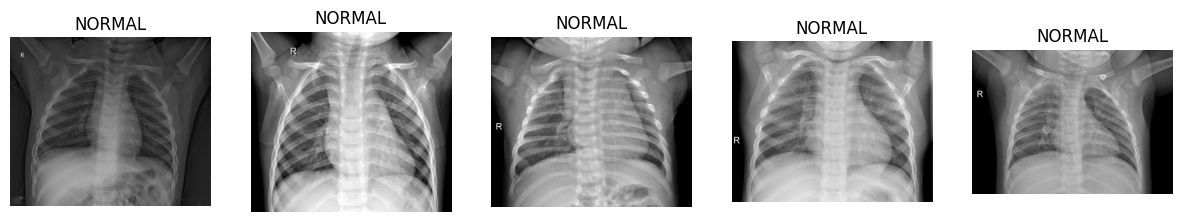

In [95]:
import os
import matplotlib.pyplot as plt
from PIL import Image

normal_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL"

sample_images = os.listdir(normal_path)[:5]

plt.figure(figsize=(15,5))

for i, img_name in enumerate(sample_images):
    img = Image.open(os.path.join(normal_path, img_name))

    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title("NORMAL")
    plt.axis('off')

plt.show()

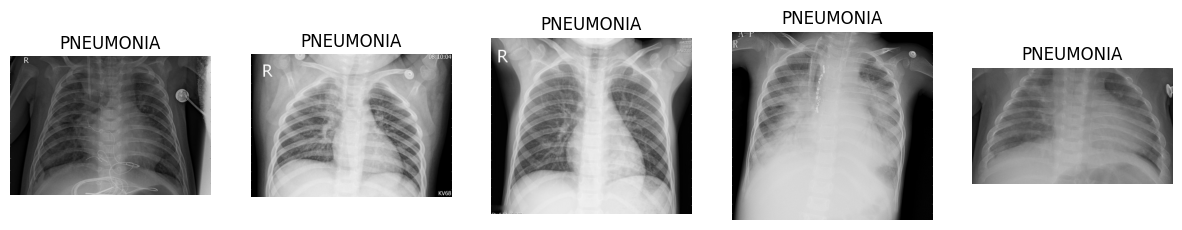

In [96]:
pneumonia_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA"

sample_images = os.listdir(pneumonia_path)[:5]

plt.figure(figsize=(15,5))

for i, img_name in enumerate(sample_images):
    img = Image.open(os.path.join(pneumonia_path, img_name))

    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title("PNEUMONIA")
    plt.axis('off')

plt.show()

In [97]:
import os

base_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"

for split in ["train", "test", "val"]:
    print(f"\n{split.upper()}")

    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(base_path, split, cls)
        print(f"{cls}: {len(os.listdir(folder))}")


TRAIN
NORMAL: 1341
PNEUMONIA: 3875

TEST
NORMAL: 234
PNEUMONIA: 390

VAL
NORMAL: 8
PNEUMONIA: 8


In [98]:
from PIL import Image
import os

normal_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL"

sample_images = os.listdir(normal_path)[:5]

for img_name in sample_images:
    img = Image.open(os.path.join(normal_path, img_name))
    print(img_name, "->", img.size)

NORMAL2-IM-0771-0001.jpeg -> (1336, 1128)
NORMAL2-IM-1294-0001-0002.jpeg -> (1400, 1260)
IM-0675-0001.jpeg -> (1218, 1032)
NORMAL2-IM-1169-0001.jpeg -> (1782, 1433)
IM-0421-0001.jpeg -> (1574, 1129)


In [99]:
# check color channels

from PIL import Image

img = Image.open(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-0771-0001.jpeg"
)

print("Mode:", img.mode)
print("Size:", img.size)

Mode: L
Size: (1336, 1128)


#Dataset Analysis
###│
###├── Classes = 2
###│   ├── NORMAL
###│   └── PNEUMONIA
###│
###├── Images = Grayscale
###│
###├── Image Sizes = Different
###│
###├── Dataset = Imbalanced
###│
###└── CNN Input Shape Not Ready Yet

In [100]:
# What is the range of pixel values?

import numpy as np
from PIL import Image

img = Image.open(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL/NORMAL2-IM-0771-0001.jpeg"
)

img_array = np.array(img)

print("Shape :", img_array.shape)
print("Min   :", img_array.min())
print("Max   :", img_array.max())

Shape : (1128, 1336)
Min   : 0
Max   : 255


In [101]:
# Create Data Generators

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [102]:
# Create the Training Generator

train_generator = train_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(128, 128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.


In [103]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [104]:
# Look at One Batch

images, labels = next(train_generator)

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : (32, 128, 128, 1)
Labels Shape : (32,)


In [105]:
print(len(train_generator))

163


In [106]:
# create the test generator.

test_generator = test_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/test",
    target_size=(128, 128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [107]:
print(test_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


###Dataset Exploration       ✅
###Class Distribution        ✅
###Image Inspection          ✅
###Image Size Check          ✅
###Pixel Range Check         ✅
###Train Generator           ✅
###Test Generator            ✅
###Label Mapping Check       ✅

###Next:
###First CNN Architecture

#A CNN is usually built from these blocks:

###Image
### ↓
###Conv2D
### ↓
###MaxPooling
### ↓
###Conv2D
### ↓
###MaxPooling
### ↓
###Flatten
### ↓
###Dense
### ↓
###Output

# Build the First CNN (Architecture Only)

In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(128,128,1)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [109]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    16,257,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257,601 (62.02 MB)

 Trainable params: 16,257,601 (62.02 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
# Compile the Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [111]:
# Inspect the Validation Generator First

val_generator = test_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/val",
    target_size=(128,128),
    color_mode="grayscale",
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

Found 16 images belonging to 2 classes.


In [112]:
# validation data is too low , lets convert it into
#Train ≈ 4173
#Val   ≈ 1043
#Test  = 624

In [113]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

In [114]:
# Create the NEW Training Generator

train_generator = train_val_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(128, 128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

Found 4173 images belonging to 2 classes.


In [115]:
val_generator = train_val_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(128, 128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 1043 images belonging to 2 classes.


###Images resized to 128×128      ✅
###Pixel values normalized        ✅
###Train Generator                ✅
###Validation Generator           ✅
###Test Generator                 ✅
###CNN Architecture               ✅
###Model Compiled                 ✅

In [116]:
!nvidia-smi

Sat Aug 15 16:32:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             32W /   70W |    2177MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [117]:
# a better begineer CNN is


# Conv2D
# ↓
# MaxPooling
# ↓
# Conv2D
# ↓
# MaxPooling
# ↓
# Flatten
# ↓
# Dense
# ↓
# Output

In [118]:
model.count_params()

16257601

In [119]:
#My dataset: 5216 images
#Model: 16.2 million parameters

# it can be overfitting

In [120]:
# let's build a better CNN:

# Conv2D(32)
# ↓
# MaxPooling

# Conv2D(64)
# ↓
# MaxPooling

# Conv2D(128)
# ↓
# MaxPooling

# Flatten

# Dense(128)

# Dense(1)

In [121]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [122]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

# Train 🚀

In [123]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [124]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 315ms/step - accuracy: 0.8795 - loss: 0.2784 - val_accuracy: 0.9482 - val_loss: 0.1378
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 295ms/step - accuracy: 0.9581 - loss: 0.1111 - val_accuracy: 0.9521 - val_loss: 0.1333
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 296ms/step - accuracy: 0.9662 - loss: 0.0951 - val_accuracy: 0.9540 - val_loss: 0.1197
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 286ms/step - accuracy: 0.9746 - loss: 0.0683 - val_accuracy: 0.9616 - val_loss: 0.1048
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 286ms/step - accuracy: 0.9784 - loss: 0.0558 - val_accuracy: 0.9712 - val_loss: 0.1004
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 287ms/step - accuracy: 0.9823 - loss: 0.0461 - val_accuracy: 0.9607 - val_loss: 0.1207
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 282ms/step - accuracy: 0.9832 - loss: 0.0467 - val_accuracy: 0.9530 - val_loss: 0.1347
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 282ms/step - accuracy: 0.9849 - loss: 0

In [125]:
# At Epoch 8

#Val Accuracy ≈ 97.1%
#Val Loss ≈ 0.095


#Train Accuracy ↑
#Validation Accuracy ↓   , it is sign of overfitting .

In [126]:
# # Current Project Status

# Dataset Analysis      ✅
# Preprocessing         ✅
# CNN Building          ✅
# Training              ✅

# Next:
# Test Set Evaluation

In [127]:
# Evaluate on the Test Set

test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.7500 - loss: 1.3492
Test Loss: 1.349219560623169
Test Accuracy: 0.75


In [128]:
# Validation Accuracy ≈ 97%
# Test Accuracy ≈ 80% .   there is a huge gap . 17 percent gap .

In [129]:
print("Train Classes :", train_generator.class_indices)
print("Val Classes   :", val_generator.class_indices)
print("Test Classes  :", test_generator.class_indices)

Train Classes : {'NORMAL': 0, 'PNEUMONIA': 1}
Val Classes   : {'NORMAL': 0, 'PNEUMONIA': 1}
Test Classes  : {'NORMAL': 0, 'PNEUMONIA': 1}


In [130]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, y_pred)

print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step
[[ 83 151]
 [  5 385]]


In [131]:
# classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        y_pred,
        target_names=['NORMAL', 'PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.94      0.35      0.52       234
   PNEUMONIA       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.83      0.67      0.67       624
weighted avg       0.80      0.75      0.71       624



In [132]:
# the model is giving answer one sided because of one sided data , pneumonia images are 3 times of normal images .
# so thats why it is giving more likely the answers as this is a pneumonia .

In [133]:
# compute the actual class weights from your training generator.
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

print(class_weights)

[1.944548   0.67306452]


In [134]:
# What Does This Mean?

# During training:

# If the model makes a mistake on NORMAL,
# the penalty is ~1.94× larger.


# If it makes a mistake on PNEUMONIA,
# the penalty is only ~0.67×.

# So we're telling the model:

# "Pay much more attention to the minority class (NORMAL)."

In [135]:
class_weight = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [136]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,912,581 (37.81 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,608,388 (25.21 MB)

In [137]:
# recreate a fresh model:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [139]:
history_weighted = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 306ms/step - accuracy: 0.8843 - loss: 0.2584 - val_accuracy: 0.9156 - val_loss: 0.2095
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 284ms/step - accuracy: 0.9549 - loss: 0.1124 - val_accuracy: 0.9674 - val_loss: 0.1027
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 284ms/step - accuracy: 0.9660 - loss: 0.0951 - val_accuracy: 0.9664 - val_loss: 0.0905
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 288ms/step - accuracy: 0.9715 - loss: 0.0735 - val_accuracy: 0.9530 - val_loss: 0.1483
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 295ms/step - accuracy: 0.9787 - loss: 0.0555 - val_accuracy: 0.9645 - val_loss: 0.1086
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 295ms/step - accuracy: 0.9815 - loss: 0.0518 - val_accuracy: 0.9655 - val_loss: 0.1075
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 294ms/step - accuracy: 0.9839 - loss: 0.0434 - val_accuracy: 0.9473 - val_loss: 0.1814
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 289ms/step - accuracy: 0.9895 - loss: 0

In [140]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.7933 - loss: 1.4780
Test Loss: 1.4779540300369263
Test Accuracy: 0.7932692170143127


In [141]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, y_pred)

print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step
[[109 125]
 [  4 386]]


In [142]:
# Now trying data augemntaion

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,

    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10
)

In [143]:
train_generator_aug = train_datagen_aug.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(128, 128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

Found 4173 images belonging to 2 classes.


In [144]:
val_generator_aug = train_datagen_aug.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(128, 128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 1043 images belonging to 2 classes.


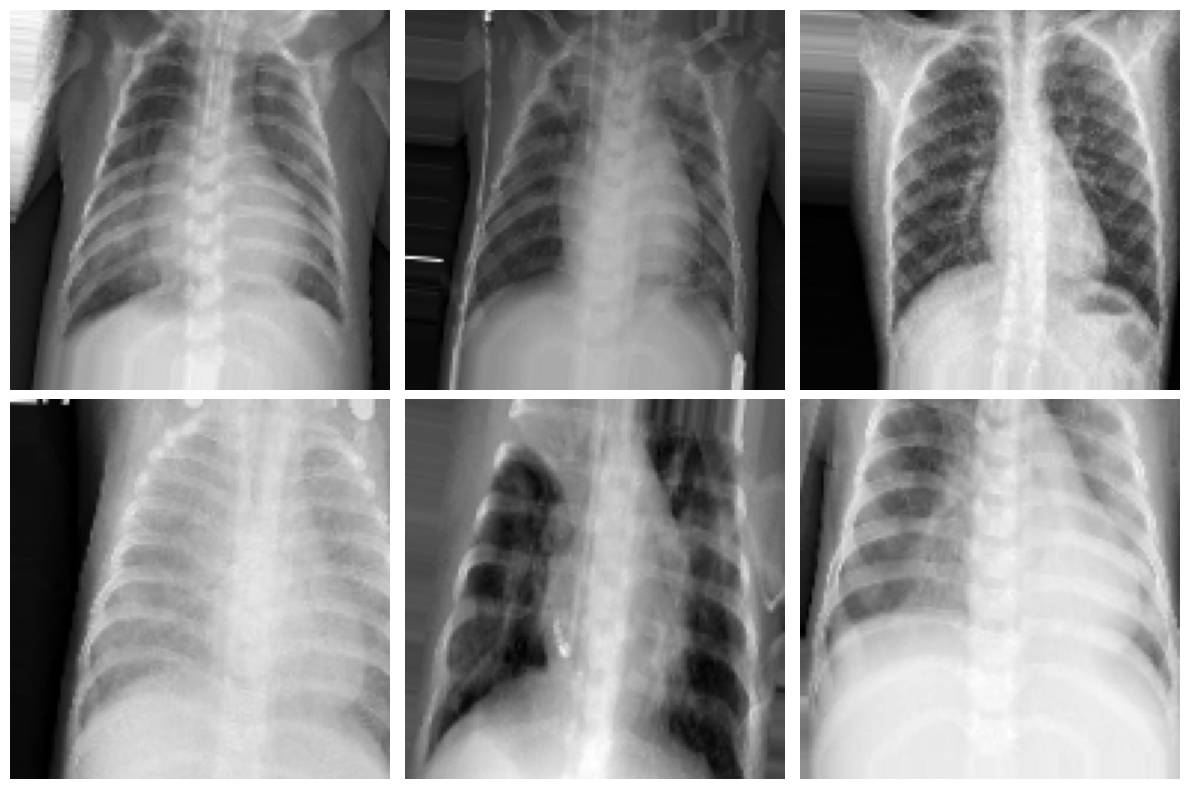

In [145]:
import matplotlib.pyplot as plt

images, labels = next(train_generator_aug)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [146]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,

    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05
)

In [147]:
train_generator_aug = train_datagen_aug.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(128,128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator_aug = train_datagen_aug.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(128,128),
    color_mode="grayscale",
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


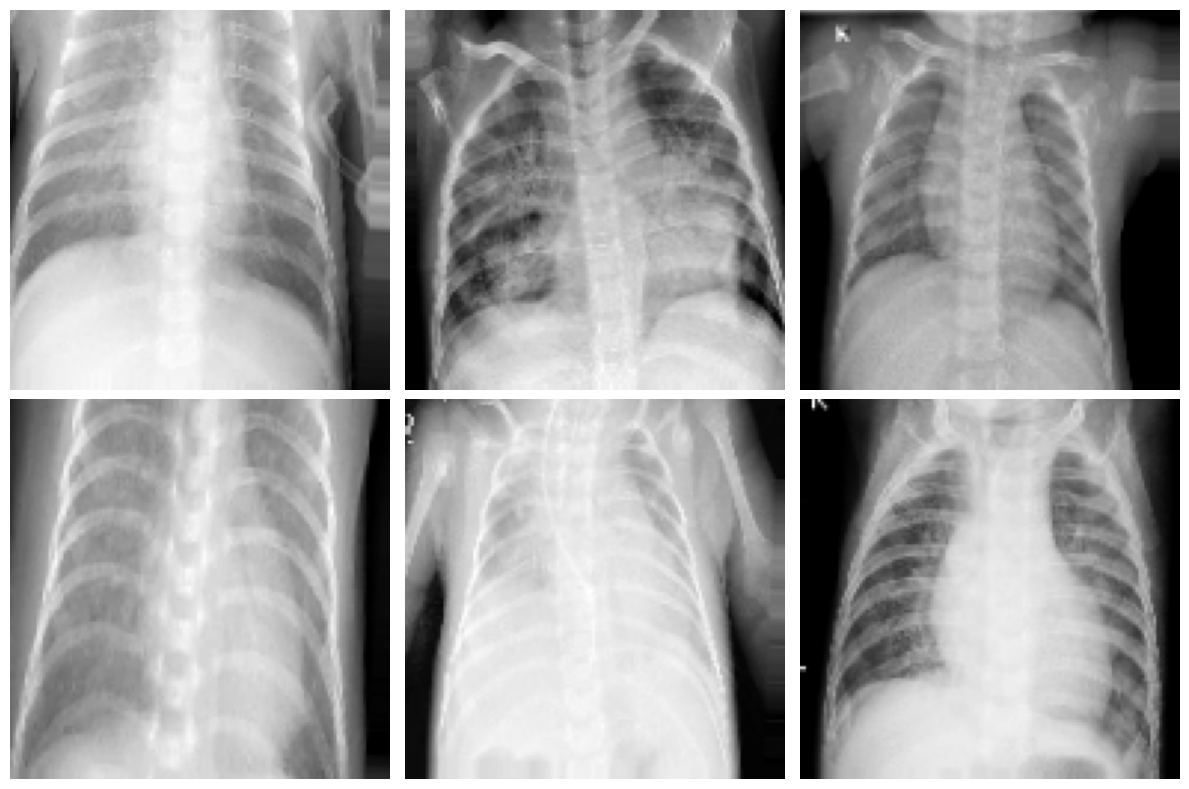

In [148]:
import matplotlib.pyplot as plt

images, labels = next(train_generator_aug)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [149]:
# Fresh model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [150]:
history_aug = model.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    class_weight=class_weight
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - accuracy: 0.7920 - loss: 0.3850 - val_accuracy: 0.9012 - val_loss: 0.2488
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 346ms/step - accuracy: 0.9226 - loss: 0.1974 - val_accuracy: 0.9281 - val_loss: 0.1903
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 354ms/step - accuracy: 0.9389 - loss: 0.1546 - val_accuracy: 0.9377 - val_loss: 0.1502
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 341ms/step - accuracy: 0.9463 - loss: 0.1406 - val_accuracy: 0.9521 - val_loss: 0.1128
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 350ms/step - accuracy: 0.9480 - loss: 0.1402 - val_accuracy: 0.9530 - val_loss: 0.1306
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 344ms/step - accuracy: 0.9554 - loss: 0.1215 - val_accuracy: 0.9453 - val_loss: 0.1741
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.9597 - loss: 0.1070 - val_accuracy: 0.9597 - val_loss: 0.1113
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 343ms/step - accuracy: 0.9633 - loss: 0

In [151]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.8189 - loss: 0.6485
Test Loss: 0.6484751105308533
Test Accuracy: 0.8189102411270142


In [152]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(
    test_generator.classes,
    y_pred
)

print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step
[[126 108]
 [  5 385]]


In [153]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        y_pred,
        target_names=['NORMAL', 'PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.96      0.54      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



In [154]:
# Early Stopping

In [155]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,912,581 (37.81 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,608,388 (25.21 MB)

In [156]:
# Create Early Stopping Callback

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print(early_stop)

In [157]:
# Create a Fresh CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model_es = Sequential()

model_es.add(Conv2D(32, (3,3), activation='relu',
                    input_shape=(128,128,1)))
model_es.add(MaxPooling2D((2,2)))

model_es.add(Conv2D(64, (3,3), activation='relu'))
model_es.add(MaxPooling2D((2,2)))

model_es.add(Conv2D(128, (3,3), activation='relu'))
model_es.add(MaxPooling2D((2,2)))

model_es.add(Flatten())

model_es.add(Dense(128, activation='relu'))

model_es.add(Dense(1, activation='sigmoid'))

model_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [158]:
history_es = model_es.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=20,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 376ms/step - accuracy: 0.7596 - loss: 0.4441 - val_accuracy: 0.9185 - val_loss: 0.2183
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 349ms/step - accuracy: 0.9274 - loss: 0.1920 - val_accuracy: 0.9223 - val_loss: 0.2206
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 346ms/step - accuracy: 0.9375 - loss: 0.1563 - val_accuracy: 0.9386 - val_loss: 0.1408
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 348ms/step - accuracy: 0.9382 - loss: 0.1547 - val_accuracy: 0.9530 - val_loss: 0.1194
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 340ms/step - accuracy: 0.9516 - loss: 0.1257 - val_accuracy: 0.9482 - val_loss: 0.1386
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 349ms/step - accuracy: 0.9542 - loss: 0.1177 - val_accuracy: 0.9540 - val_loss: 0.1127
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 346ms/step - accuracy: 0.9600 - loss: 0.1059 - val_accuracy: 0.9406 - val_loss: 0.1510
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.9653 - loss: 0

In [159]:
test_loss_es, test_accuracy_es = model_es.evaluate(test_generator)

print("Test Loss:", test_loss_es)
print("Test Accuracy:", test_accuracy_es)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.7853 - loss: 0.7738
Test Loss: 0.7737799882888794
Test Accuracy: 0.7852563858032227


In [160]:
# fresh CNN with Dropout.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model_do = Sequential()

model_do.add(Conv2D(32, (3,3), activation='relu',
                    input_shape=(128,128,1)))
model_do.add(MaxPooling2D((2,2)))

model_do.add(Conv2D(64, (3,3), activation='relu'))
model_do.add(MaxPooling2D((2,2)))

model_do.add(Conv2D(128, (3,3), activation='relu'))
model_do.add(MaxPooling2D((2,2)))

model_do.add(Flatten())

model_do.add(Dense(128, activation='relu'))

model_do.add(Dropout(0.5))

model_do.add(Dense(1, activation='sigmoid'))

model_do.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [161]:
history_do = model_do.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    class_weight=class_weight
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 361ms/step - accuracy: 0.8059 - loss: 0.3917 - val_accuracy: 0.8763 - val_loss: 0.2781
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 346ms/step - accuracy: 0.9080 - loss: 0.2280 - val_accuracy: 0.9128 - val_loss: 0.2068
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 344ms/step - accuracy: 0.9257 - loss: 0.1878 - val_accuracy: 0.9070 - val_loss: 0.2172
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 348ms/step - accuracy: 0.9324 - loss: 0.1782 - val_accuracy: 0.9291 - val_loss: 0.1877
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 339ms/step - accuracy: 0.9410 - loss: 0.1454 - val_accuracy: 0.9099 - val_loss: 0.2242
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 42s 325ms/step - accuracy: 0.9458 - loss: 0.1480 - val_accuracy: 0.9252 - val_loss: 0.1927
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 343ms/step - accuracy: 0.9487 - loss: 0.1382 - val_accuracy: 0.9118 - val_loss: 0.2057
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 340ms/step - accuracy: 0.9554 - loss: 0

In [162]:
test_loss_do, test_accuracy_do = model_do.evaluate(test_generator)

print("Test Loss:", test_loss_do)
print("Test Accuracy:", test_accuracy_do)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.8157 - loss: 0.6121
Test Loss: 0.6121376156806946
Test Accuracy: 0.8157051205635071


In [163]:
# Batch Normalization

In [164]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    BatchNormalization
)

model_bn = Sequential()

model_bn.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,1)
    )
)
model_bn.add(BatchNormalization())
model_bn.add(MaxPooling2D((2,2)))

model_bn.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model_bn.add(BatchNormalization())
model_bn.add(MaxPooling2D((2,2)))

model_bn.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)
model_bn.add(BatchNormalization())
model_bn.add(MaxPooling2D((2,2)))

model_bn.add(Flatten())

model_bn.add(Dense(128, activation='relu'))

model_bn.add(Dense(1, activation='sigmoid'))

model_bn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [165]:
model_bn.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,089 (12.61 MB)

 Trainable params: 3,304,641 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [166]:
history_bn = model_bn.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    class_weight=class_weight
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 55s 379ms/step - accuracy: 0.8967 - loss: 0.4965 - val_accuracy: 0.7430 - val_loss: 22.3805
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 346ms/step - accuracy: 0.9494 - loss: 0.1550 - val_accuracy: 0.7430 - val_loss: 14.1449
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 344ms/step - accuracy: 0.9346 - loss: 0.1927 - val_accuracy: 0.7430 - val_loss: 9.2529
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 333ms/step - accuracy: 0.9490 - loss: 0.1338 - val_accuracy: 0.7478 - val_loss: 2.6678
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 330ms/step - accuracy: 0.9554 - loss: 0.1091 - val_accuracy: 0.7095 - val_loss: 0.7269
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 331ms/step - accuracy: 0.9609 - loss: 0.1096 - val_accuracy: 0.8360 - val_loss: 0.6056
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 342ms/step - accuracy: 0.9614 - loss: 0.0975 - val_accuracy: 0.8610 - val_loss: 0.3969
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 342ms/step - accuracy: 0.9691 - loss: